<a href="https://www.kaggle.com/code/jresona/notebook7225b53ffd?scriptVersionId=354969308" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anjalibhegam/multimodal-sports-injury-dataset/README.md
/kaggle/input/datasets/anjalibhegam/multimodal-sports-injury-dataset/multimodal_sports_injury_dataset.csv


In [2]:
# Cell 1: Load
import glob, time, os, json
import numpy as np
import pandas as pd

csv_path = glob.glob("/kaggle/input/**/*.csv", recursive=True)[0]
raw = pd.read_csv(csv_path)
print("Loaded:", csv_path)
print("Rows, Columns:", raw.shape)

Loaded: /kaggle/input/datasets/anjalibhegam/multimodal-sports-injury-dataset/multimodal_sports_injury_dataset.csv
Rows, Columns: (15420, 29)


In [3]:
# Cell 2: Keep only your factors
keep_cols = ["athlete_id", "session_id",
             "training_duration", "training_intensity", "training_load",
             "heart_rate", "sleep_quality", "recovery_score", "stress_level",
             "fatigue_index"]
df = raw[keep_cols].copy()
print(df.shape)
df.head()

(15420, 10)


,athlete_id,session_id,training_duration,training_intensity,training_load,heart_rate,sleep_quality,recovery_score,stress_level,fatigue_index
0,1,1,79.106564,5.678475,548.417962,NaN,5.466370,77.899691,0.375825,45.028687
1,1,2,116.954654,NaN,538.043815,40.000000,6.899090,74.845323,0.279165,42.254717
2,1,3,96.354742,6.643242,647.784339,76.174609,9.574152,83.538316,0.334061,61.870056
3,1,4,97.619130,6.194427,336.553431,100.543724,7.614297,79.966618,0.218766,50.268845
4,1,5,83.155527,5.835804,496.076352,78.001235,5.631979,56.945979,0.484086,29.233575


In [4]:
# Cell 3: Cleaning checks
print("=== MISSING VALUES ===")
print(df.isnull().sum())
print("\nFully duplicated rows:", df.duplicated().sum())
print("Repeated athlete+session pairs:", df.duplicated(subset=["athlete_id", "session_id"]).sum())
print("\n=== VALUE RANGES (outliers are NOT deleted) ===")
print(df.describe().T[["min", "mean", "max"]].round(2))

=== MISSING VALUES ===
athlete_id              0
session_id              0
training_duration       0
training_intensity    632
training_load           0
heart_rate            354
sleep_quality         493
recovery_score          0
stress_level            0
fatigue_index           0
dtype: int64

Fully duplicated rows: 0
Repeated athlete+session pairs: 0

=== VALUE RANGES (outliers are NOT deleted) ===
                       min    mean      max
athlete_id            1.00   78.55   156.00
session_id            1.00   49.93   101.00
training_duration    30.00   87.79   180.00
training_intensity    2.00    6.40    10.00
training_load       150.00  670.53  2632.64
heart_rate           40.00   72.69   159.27
sleep_quality         1.16    5.82    10.00
recovery_score        8.90   55.20    98.00
stress_level          0.10    0.42     0.95
fatigue_index        15.00   59.70   270.19


In [5]:
# Cell 4: Sort in time order and number each athlete's sessions
df = df.sort_values(["athlete_id", "session_id"]).reset_index(drop=True)
df["session_number"] = df.groupby("athlete_id").cumcount() + 1
print(df.groupby("athlete_id")["session_number"].max().describe().round(1))

count    156.0
mean      98.8
std        0.9
min       98.0
25%       98.0
50%       99.0
75%       99.0
max      101.0
Name: session_number, dtype: float64


In [6]:
# Cell 5: Previous-session features (only EARLIER sessions: shift(1) comes first)
g = df.groupby("athlete_id")

for w in [7, 14]:
    df[f"load_sum_{w}"] = g["training_load"].transform(
        lambda s: s.shift(1).rolling(w, min_periods=w).sum())
    df[f"load_mean_{w}"] = g["training_load"].transform(
        lambda s: s.shift(1).rolling(w, min_periods=w).mean())
    df[f"load_minus_mean_{w}"] = df["training_load"] - df[f"load_mean_{w}"]   # today vs history
    df[f"load_ratio_{w}"] = df["training_load"] / df[f"load_mean_{w}"]        # today vs history

for col in ["training_intensity", "heart_rate", "sleep_quality",
            "recovery_score", "stress_level"]:
    for w in [7, 14]:
        df[f"{col}_mean_{w}"] = g[col].transform(
            lambda s: s.shift(1).rolling(w, min_periods=3).mean())

df = df.replace([np.inf, -np.inf], np.nan)
print("Total columns now:", df.shape[1])

Total columns now: 29


In [7]:
# Cell 6: Leakage proof and overlap check
a = df[df["athlete_id"] == df["athlete_id"].iloc[0]].reset_index(drop=True)
row15 = a[a["session_number"] == 15].iloc[0]

manual_sum7  = a[(a.session_number >= 8) & (a.session_number <= 14)]["training_load"].sum()
manual_sum14 = a[(a.session_number >= 1) & (a.session_number <= 14)]["training_load"].sum()

assert np.isclose(row15["load_sum_7"], manual_sum7)
assert np.isclose(row15["load_sum_14"], manual_sum14)
print("OK: windows use only earlier sessions.")
print("Correlation of 7- and 14-session load totals:",
      round(df["load_sum_7"].corr(df["load_sum_14"]), 3))      # earlier run: 0.729

OK: windows use only earlier sessions.
Correlation of 7- and 14-session load totals: 0.729


In [8]:
# Cell 7: Time-ordered split and fatigue classes
model_df = df[df["session_number"] >= 15].copy()          # session 15 = first prediction

train_df = model_df[model_df["session_number"] <= 75].copy()
q1, q2 = train_df["fatigue_index"].quantile([1/3, 2/3])   # cut points from TRAINING data only
print("Class cut points:", round(q1, 2), round(q2, 2))     # expect 47.4 and 68.77

def to_class(x):
    return 0 if x <= q1 else (1 if x <= q2 else 2)

class_names = ["Low", "Moderate", "High"]
model_df["fatigue_class"] = model_df["fatigue_index"].apply(to_class)

train_df = model_df[model_df["session_number"] <= 75].copy()   # sessions 15-75
test_df  = model_df[model_df["session_number"] >= 76].copy()   # sessions 76 onward

print("Train rows:", len(train_df), "| Test rows:", len(test_df))   # expect 9516 and 3720
print(train_df["fatigue_class"].value_counts().sort_index())
print(test_df["fatigue_class"].value_counts().sort_index())

Class cut points: 47.4 68.77
Train rows: 9516 | Test rows: 3720
fatigue_class
0    3172
1    3172
2    3172
Name: count, dtype: int64
fatigue_class
0    1304
1    1232
2    1184
Name: count, dtype: int64


In [9]:
# Cell 8: Feature groups
today_feats = ["training_duration", "training_intensity", "training_load",
               "heart_rate", "sleep_quality", "recovery_score", "stress_level"]

comparison_feats = ["load_minus_mean_7", "load_minus_mean_14",
                    "load_ratio_7", "load_ratio_14"]

history_pure = (["load_sum_7", "load_sum_14", "load_mean_7", "load_mean_14"] +
                [f"{c}_mean_{w}" for c in ["training_intensity", "heart_rate", "sleep_quality",
                                           "recovery_score", "stress_level"] for w in [7, 14]])

features = today_feats + history_pure + comparison_feats

feature_group = {}
for f in today_feats:      feature_group[f] = "Today"
for f in history_pure:     feature_group[f] = "History (previous sessions)"
for f in comparison_feats: feature_group[f] = "Today vs history"

X_train, y_train = train_df[features], train_df["fatigue_class"]
X_test,  y_test  = test_df[features],  test_df["fatigue_class"]

print("Today:", len(today_feats), "| History:", len(history_pure),
      "| Today vs history:", len(comparison_feats), "| Total:", len(features))   # 7, 14, 4, 25
print("fatigue_index in features?", "fatigue_index" in features)               # must be False

Today: 7 | History: 14 | Today vs history: 4 | Total: 25
fatigue_index in features? False


In [10]:
# Cell 9: Helpers and the main Random Forest (300 trees, default settings, not tuned)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, log_loss,
                             confusion_matrix, classification_report)

def make_rf(**kw):
    params = dict(n_estimators=300, random_state=42, n_jobs=-1)
    params.update(kw)
    return Pipeline([
        ("fill_missing", SimpleImputer(strategy="median")),   # medians learned from training data only
        ("model", RandomForestClassifier(**params)),
    ])

def score(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc_ovr_macro": roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
    }

def run_rf(feats, tr, te, **kw):
    pipe = make_rf(**kw)
    t0 = time.perf_counter()
    pipe.fit(tr[feats], tr["fatigue_class"])
    train_t = time.perf_counter() - t0
    t0 = time.perf_counter()
    pred = pipe.predict(te[feats])
    proba = pipe.predict_proba(te[feats])
    pred_t = time.perf_counter() - t0
    return pipe, pred, proba, score(te["fatigue_class"], pred, proba), train_t, pred_t

main_pipe, y_pred, y_proba, main_metrics, train_wall_time, predict_wall_time = run_rf(features, train_df, test_df)

print(f"Training wall time:   {train_wall_time:.4f} seconds")
print(f"Prediction wall time: {predict_wall_time:.4f} seconds")

Training wall time:   6.9541 seconds
Prediction wall time: 0.2377 seconds


In [11]:
# Cell 10: Evaluate the main model
for k, v in main_metrics.items():
    print(f"{k:20s}: {v:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix (rows = true, columns = predicted):")
print(pd.DataFrame(cm, index=[f"true_{n}" for n in class_names],
                   columns=[f"pred_{n}" for n in class_names]))
print("\n", classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

accuracy            : 0.6680
balanced_accuracy   : 0.6677
precision_macro     : 0.6696
recall_macro        : 0.6677
f1_macro            : 0.6686
f1_weighted         : 0.6689
roc_auc_ovr_macro   : 0.8424

Confusion matrix (rows = true, columns = predicted):
               pred_Low  pred_Moderate  pred_High
true_Low            948            318         38
true_Moderate       302            670        260
true_High            39            278        867

               precision    recall  f1-score   support

         Low       0.74      0.73      0.73      1304
    Moderate       0.53      0.54      0.54      1232
        High       0.74      0.73      0.74      1184

    accuracy                           0.67      3720
   macro avg       0.67      0.67      0.67      3720
weighted avg       0.67      0.67      0.67      3720



In [12]:
# Cell 11: Save metrics, wall time, per-class results, importances and test predictions
results = pd.DataFrame([{
    "model": "Random Forest",
    "train_rows": len(X_train), "test_rows": len(X_test), "n_features": len(features),
    "train_wall_time_sec": round(train_wall_time, 4),
    "predict_wall_time_sec": round(predict_wall_time, 4),
    "total_wall_time_sec": round(train_wall_time + predict_wall_time, 4),
    **{k: round(v, 4) for k, v in main_metrics.items()},
}])
results.to_csv("/kaggle/working/random_forest_metrics.csv", index=False)

per_class = pd.DataFrame(classification_report(
    y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)).T
per_class.to_csv("/kaggle/working/random_forest_per_class.csv")

rf_imp = pd.DataFrame({
    "importance": main_pipe.named_steps["model"].feature_importances_,
    "group": [feature_group[f] for f in features]}, index=features
).sort_values("importance", ascending=False)
rf_imp.to_csv("/kaggle/working/random_forest_feature_importance.csv")

test_out = test_df[["athlete_id", "session_id", "session_number", "fatigue_index", "fatigue_class"] + features].copy()
test_out["true_class"] = test_out["fatigue_class"].map(dict(enumerate(class_names)))
test_out["predicted_class"] = pd.Series(y_pred, index=test_out.index).map(dict(enumerate(class_names)))
test_out["correct"] = test_out["true_class"] == test_out["predicted_class"]
for i, name in enumerate(class_names):
    test_out[f"prob_{name}"] = y_proba[:, i].round(4)
test_out.to_csv("/kaggle/working/random_forest_test_predictions.csv", index=False)

print(results.T)
print("\nTop 10 impurity importances:")
print(rf_imp.head(10).round(4))

                                   0
model                  Random Forest
train_rows                      9516
test_rows                       3720
n_features                        25
train_wall_time_sec           6.9541
predict_wall_time_sec         0.2377
total_wall_time_sec           7.1918
accuracy                       0.668
balanced_accuracy             0.6677
precision_macro               0.6696
recall_macro                  0.6677
f1_macro                      0.6686
f1_weighted                   0.6689
roc_auc_ovr_macro             0.8424

Top 10 impurity importances:
                       importance                        group
training_load              0.1345                        Today
load_ratio_14              0.0834             Today vs history
load_minus_mean_14         0.0767             Today vs history
load_ratio_7               0.0676             Today vs history
load_minus_mean_7          0.0513             Today vs history
recovery_score             0.0451    

In [13]:
ablation_sets = {
    "A. Today only":                         today_feats,
    "B. History only (past sessions)":       history_pure,
    "C. Today + history":                    today_feats + history_pure,
    "D. Today + history + comparison (all)": features,
}

rows = []
for name, feats in ablation_sets.items():
    _, p, pr, m, t_tr, t_pr = run_rf(feats, train_df, test_df)
    rows.append({"feature_set": name, "n_features": len(feats),
                 "train_wall_time_sec": round(t_tr, 4),
                 "predict_wall_time_sec": round(t_pr, 4),
                 **{k: round(v, 4) for k, v in m.items()}})

ablation = pd.DataFrame(rows)
ablation.to_csv("/kaggle/working/rf_ablation.csv", index=False)
print(ablation[["feature_set", "n_features", "accuracy", "f1_macro", "roc_auc_ovr_macro"]].to_string(index=False))

                          feature_set  n_features  accuracy  f1_macro  roc_auc_ovr_macro
                        A. Today only           7    0.6640    0.6650             0.8437
      B. History only (past sessions)          14    0.3605    0.3599             0.5290
                   C. Today + history          21    0.6656    0.6652             0.8410
D. Today + history + comparison (all)          25    0.6680    0.6686             0.8424


In [14]:
RETRAIN_EVERY = 1     # retrain after every session. Use 5 for fewer, faster retrains.

max_sn = int(model_df["session_number"].max())
starts = list(range(76, max_sn + 1, RETRAIN_EVERY))

upd_true, upd_pred, upd_proba = [], [], []
upd_fit_time, n_fits = 0.0, 0

for s in starts:
    tr = model_df[model_df["session_number"] < s]
    te = model_df[(model_df["session_number"] >= s) & (model_df["session_number"] < s + RETRAIN_EVERY)]
    if len(te) == 0:
        continue
    pipe = make_rf()
    t0 = time.perf_counter()
    pipe.fit(tr[features], tr["fatigue_class"])
    upd_fit_time += time.perf_counter() - t0
    n_fits += 1
    upd_pred.append(pipe.predict(te[features]))
    upd_proba.append(pipe.predict_proba(te[features]))
    upd_true.append(te["fatigue_class"].values)

upd_true  = np.concatenate(upd_true)
upd_pred  = np.concatenate(upd_pred)
upd_proba = np.concatenate(upd_proba)
updating_metrics = score(upd_true, upd_pred, upd_proba)

wf = pd.DataFrame([
    {"version": "Frozen (trained once on sessions 15-75)", "n_fits": 1,
     "total_train_wall_time_sec": round(train_wall_time, 4),
     **{k: round(v, 4) for k, v in main_metrics.items()}},
    {"version": f"Updating (retrained every {RETRAIN_EVERY} session(s))", "n_fits": n_fits,
     "total_train_wall_time_sec": round(upd_fit_time, 4),
     **{k: round(v, 4) for k, v in updating_metrics.items()}},
])
wf.to_csv("/kaggle/working/rf_walk_forward.csv", index=False)
print("Rows evaluated (updating):", len(upd_true), "| rows evaluated (frozen):", len(y_test))
print(wf[["version", "n_fits", "accuracy", "f1_macro", "roc_auc_ovr_macro", "total_train_wall_time_sec"]].to_string(index=False))

Rows evaluated (updating): 3720 | rows evaluated (frozen): 3720
                                version  n_fits  accuracy  f1_macro  roc_auc_ovr_macro  total_train_wall_time_sec
Frozen (trained once on sessions 15-75)       1    0.6680    0.6686             0.8424                     6.9541
Updating (retrained every 1 session(s))      26    0.6648    0.6646             0.8438                   220.5010


SHAP array shape (rows, features, classes): (500, 25, 3)

=== Top 10 features ===
                                          group  shap_overall
training_load                             Today        0.0763
load_ratio_14                  Today vs history        0.0444
load_minus_mean_14             Today vs history        0.0382
load_ratio_7                   Today vs history        0.0335
recovery_score                            Today        0.0238
load_minus_mean_7              Today vs history        0.0231
training_intensity                        Today        0.0103
training_duration                         Today        0.0092
sleep_quality                             Today        0.0090
load_sum_14         History (previous sessions)        0.0086

=== Share of model influence by group (%) ===
group
History (previous sessions)    19.82
Today                          39.71
Today vs history               40.47
Name: shap_overall, dtype: float64


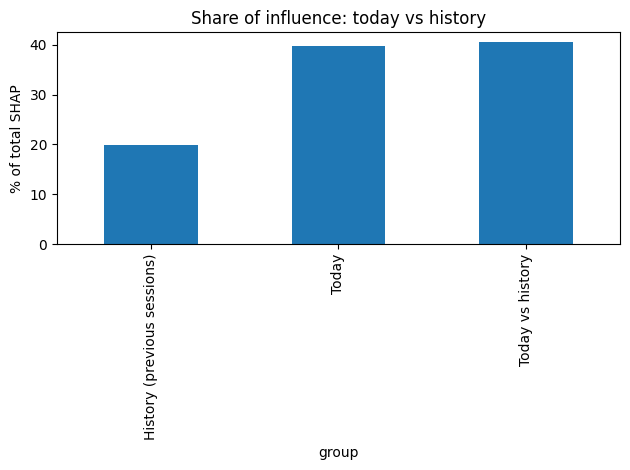

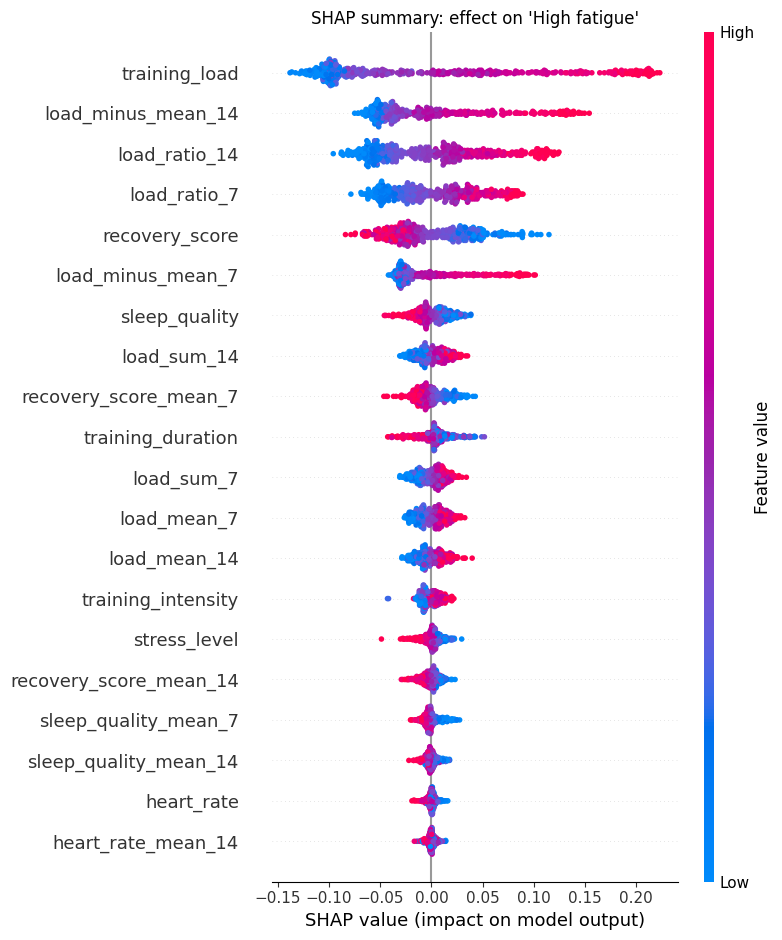


Why this session was predicted 'Moderate' (top 8 factors):
                      shap_value                        group
training_load              0.073                        Today
load_ratio_14              0.032             Today vs history
recovery_score             0.029                        Today
load_ratio_7               0.025             Today vs history
load_minus_mean_14         0.023             Today vs history
training_intensity         0.020                        Today
sleep_quality_mean_7      -0.019  History (previous sessions)
load_minus_mean_7          0.018             Today vs history


In [15]:
# Cell 14: SHAP with the "today vs history" grouping (uses a 500-row random sample of the test set for speed)
!pip install shap -q
import shap
import matplotlib.pyplot as plt

imp_step = main_pipe.named_steps["fill_missing"]
rf_model = main_pipe.named_steps["model"]
Xte_i = pd.DataFrame(imp_step.transform(X_test), columns=features, index=X_test.index)

rng = np.random.default_rng(0)
shap_idx = rng.choice(len(Xte_i), size=min(500, len(Xte_i)), replace=False)
Xs = Xte_i.iloc[shap_idx]

explainer = shap.TreeExplainer(rf_model)
sv = explainer.shap_values(Xs, check_additivity=False)
if isinstance(sv, list):
    sv = np.stack(sv, axis=-1)                    # -> (rows, features, classes)
print("SHAP array shape (rows, features, classes):", sv.shape)

mean_abs = np.abs(sv).mean(axis=0)
imp = pd.DataFrame(mean_abs, index=features, columns=[f"shap_{n}" for n in class_names])
imp["shap_overall"] = imp.mean(axis=1)
imp["group"] = imp.index.map(feature_group)
imp = imp.sort_values("shap_overall", ascending=False)

group_share = imp.groupby("group")["shap_overall"].sum()
group_pct = (100 * group_share / group_share.sum()).round(2)

print("\n=== Top 10 features ===")
print(imp[["group", "shap_overall"]].head(10).round(4))
print("\n=== Share of model influence by group (%) ===")
print(group_pct)

imp.to_csv("/kaggle/working/rf_shap_feature_importance.csv")
group_pct.rename("percent_of_total_shap").to_csv("/kaggle/working/rf_shap_group_share.csv")

group_pct.plot(kind="bar", title="Share of influence: today vs history")
plt.ylabel("% of total SHAP"); plt.tight_layout()
plt.savefig("/kaggle/working/rf_shap_group_share.png", dpi=150); plt.show()

shap.summary_plot(sv[:, :, 2], Xs, feature_names=features, show=False)
plt.title("SHAP summary: effect on 'High fatigue'")
plt.tight_layout(); plt.savefig("/kaggle/working/rf_shap_summary_high.png", dpi=150); plt.show()

# Explain ONE prediction
j = 0
pred_cls = int(rf_model.predict(Xs.iloc[[j]].values)[0])
contrib = pd.Series(sv[j, :, pred_cls], index=features)
contrib = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(8)
print(f"\nWhy this session was predicted '{class_names[pred_cls]}' (top 8 factors):")
print(pd.DataFrame({"shap_value": contrib.round(3), "group": contrib.index.map(feature_group)}))

In [16]:
# Cell 15: SHAP consistency check + permutation importance
cls, j = 2, 0
proba_j = rf_model.predict_proba(Xs.iloc[[j]].values)[0, cls]
base = np.atleast_1d(explainer.expected_value)[cls]
print("Baseline + sum of SHAP:", round(float(base + sv[j, :, cls].sum()), 4))
print("Model probability:     ", round(float(proba_j), 4))     # should be very close

from sklearn.inspection import permutation_importance
pi = permutation_importance(main_pipe, X_test, y_test, scoring="f1_macro",
                            n_repeats=5, random_state=42, n_jobs=1)
perm = pd.DataFrame({"f1_drop_when_shuffled": pi.importances_mean,
                     "std": pi.importances_std,
                     "group": [feature_group[f] for f in features]}, index=features
                   ).sort_values("f1_drop_when_shuffled", ascending=False)
perm.to_csv("/kaggle/working/rf_permutation_importance.csv")
print("\nPermutation importance (bigger drop = more important):")
print(perm.head(10).round(4))

Baseline + sum of SHAP: 0.2133
Model probability:      0.2133

Permutation importance (bigger drop = more important):
                    f1_drop_when_shuffled     std                        group
training_load                      0.0323  0.0035                        Today
recovery_score                     0.0096  0.0048                        Today
training_duration                  0.0076  0.0015                        Today
load_ratio_14                      0.0062  0.0039             Today vs history
training_intensity                 0.0049  0.0018                        Today
load_mean_7                        0.0045  0.0014  History (previous sessions)
load_mean_14                       0.0039  0.0018  History (previous sessions)
load_minus_mean_14                 0.0038  0.0010             Today vs history
load_ratio_7                       0.0038  0.0021             Today vs history
load_sum_14                        0.0033  0.0012  History (previous sessions)


In [17]:
# Cell 16: Counterfactual "what-if" (model-based, not medical or coaching advice)
adjustable = ["sleep_quality", "recovery_score", "stress_level"]
ranges = {c: (train_df[c].min(), train_df[c].max()) for c in adjustable}

def counterfactual(row, pipe, current_class, n_grid=60):
    trials, meta = [], []
    for col in adjustable:
        lo, hi = ranges[col]
        for val in np.linspace(lo, hi, n_grid):
            t = row.copy()
            t[col] = val
            trials.append(t)
            meta.append((col, val))
    T = pd.DataFrame(trials)[features].astype(float)
    preds = pipe.predict(T)

    found = []
    for col in adjustable:
        lo, hi = ranges[col]
        best = None
        for (c, val), p in zip(meta, preds):
            if c == col and p < current_class:
                change = abs(val - row[col])
                if best is None or change < best[1]:
                    best = (val, change, int(p))
        if best:
            found.append({"factor": col, "current": round(float(row[col]), 2),
                          "change_to": round(float(best[0]), 2),
                          "change_size": round(float(best[1]), 2),
                          "relative_change_%": round(100 * best[1] / (hi - lo), 1),
                          "new_class": class_names[best[2]]})
    return pd.DataFrame(found).sort_values("relative_change_%") if found else pd.DataFrame()

high_pos = np.where(y_pred == 2)[0][0]
example_meta = test_df.iloc[high_pos]
print("Example: athlete", int(example_meta["athlete_id"]), "session", int(example_meta["session_number"]),
      "-> predicted class: High")

advice = counterfactual(X_test.iloc[high_pos], main_pipe, current_class=2)
print(advice if len(advice) else "No single-factor change was enough.")
advice.to_csv("/kaggle/working/rf_counterfactual_example.csv", index=False)

Example: athlete 1 session 76 -> predicted class: High
           factor  current  change_to  change_size  relative_change_%  \
1  recovery_score    37.69      48.17        10.47               11.8   
0   sleep_quality     4.03       5.65         1.62               18.4   

  new_class  
1  Moderate  
0  Moderate  


In [18]:
g = df.groupby("athlete_id")
df["fatigue_prev1"]  = g["fatigue_index"].shift(1)            # shift first: only EARLIER sessions
df["fatigue_mean_7"] = g["fatigue_index"].transform(
    lambda s: s.shift(1).rolling(7, min_periods=3).mean())

pf = model_df.copy()
pf[["fatigue_prev1", "fatigue_mean_7"]] = df.loc[pf.index, ["fatigue_prev1", "fatigue_mean_7"]]
pf_train = pf[pf["session_number"] <= 75]
pf_test  = pf[pf["session_number"] >= 76]
prev_fatigue = ["fatigue_prev1", "fatigue_mean_7"]

sets = {
    "A. Today only": today_feats,
    "E. Today + previous fatigue": today_feats + prev_fatigue,
    "F. Today + history + previous fatigue": today_feats + history_pure + prev_fatigue,
}
rows = []
for name, feats in sets.items():
    _, p, pr, m, _, _ = run_rf(feats, pf_train, pf_test)
    rows.append({"feature_set": name, "n_features": len(feats),
                 **{k: round(v, 4) for k, v in m.items()}})
out = pd.DataFrame(rows)
out.to_csv("/kaggle/working/rf_ablation_prev_fatigue.csv", index=False)
print(out[["feature_set", "n_features", "accuracy", "f1_macro", "roc_auc_ovr_macro"]].to_string(index=False))

                          feature_set  n_features  accuracy  f1_macro  roc_auc_ovr_macro
                        A. Today only           7    0.6640    0.6650             0.8437
          E. Today + previous fatigue           9    0.6642    0.6650             0.8446
F. Today + history + previous fatigue          23    0.6667    0.6662             0.8416


In [19]:
# Cell 18: Choose the best forest settings on a VALIDATION set (test set untouched)
core_df = model_df[model_df["session_number"] <= 60].copy()                       # train
val_df  = model_df[(model_df["session_number"] >= 61) &
                   (model_df["session_number"] <= 75)].copy()                     # validation
print("Core train:", len(core_df), "| Validation:", len(val_df))

rows = []
for leaf in [1, 3, 5, 10, 20, 40]:
    for mf in ["sqrt", 0.5]:
        pipe = make_rf(min_samples_leaf=leaf, max_features=mf)
        pipe.fit(core_df[features], core_df["fatigue_class"])
        proba = pipe.predict_proba(val_df[features])
        pred = pipe.predict(val_df[features])
        rows.append({"min_samples_leaf": leaf, "max_features": str(mf),
                     "val_logloss": round(log_loss(val_df["fatigue_class"], proba), 4),
                     "val_f1_macro": round(f1_score(val_df["fatigue_class"], pred, average="macro"), 4)})

tune = pd.DataFrame(rows).sort_values("val_logloss")
tune.to_csv("/kaggle/working/rf_tuning_validation.csv", index=False)
print(tune.to_string(index=False))

best_row = tune.iloc[0]
best_leaf = int(best_row["min_samples_leaf"])
best_mf = best_row["max_features"]
best_mf = float(best_mf) if best_mf.replace(".", "", 1).isdigit() else best_mf
print("\nChosen on validation: min_samples_leaf =", best_leaf, "| max_features =", best_mf)

Core train: 7176 | Validation: 2340
 min_samples_leaf max_features  val_logloss  val_f1_macro
               20          0.5       0.6995        0.6629
               40          0.5       0.7000        0.6722
               10          0.5       0.7001        0.6661
                5          0.5       0.7027        0.6603
               10         sqrt       0.7031        0.6692
                5         sqrt       0.7041        0.6628
               20         sqrt       0.7043        0.6690
                3          0.5       0.7044        0.6607
                1         sqrt       0.7063        0.6650
               40         sqrt       0.7069        0.6674
                3         sqrt       0.7195        0.6606
                1          0.5       0.7218        0.6642

Chosen on validation: min_samples_leaf = 20 | max_features = 0.5


Best number of trees (lowest validation log-loss): 320
Validation log-loss at best: 0.6992


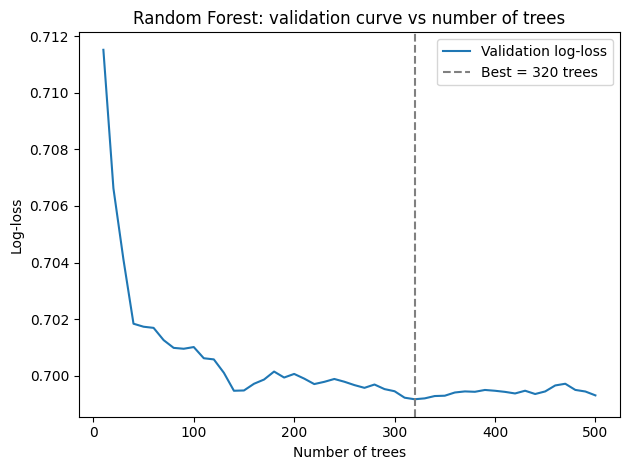

In [20]:
# Cell 19: Best number of trees (the Random Forest equivalent of "best epoch")
imp_c = SimpleImputer(strategy="median").fit(core_df[features])
Xc, yc = imp_c.transform(core_df[features]), core_df["fatigue_class"]
Xv, yv = imp_c.transform(val_df[features]),  val_df["fatigue_class"]

rf_ws = RandomForestClassifier(n_estimators=10, warm_start=True,
                               min_samples_leaf=best_leaf, max_features=best_mf,
                               random_state=42, n_jobs=-1)

rows = []
for n in range(10, 501, 10):
    rf_ws.set_params(n_estimators=n)
    rf_ws.fit(Xc, yc)                     # warm_start: only the NEW trees are added
    p = rf_ws.predict_proba(Xv)
    rows.append({"n_trees": n,
                 "val_logloss": log_loss(yv, p),
                 "val_f1_macro": f1_score(yv, p.argmax(axis=1), average="macro"),
                 "val_accuracy": accuracy_score(yv, p.argmax(axis=1))})

curve = pd.DataFrame(rows)
curve.to_csv("/kaggle/working/rf_tree_curve.csv", index=False)

best_n = int(curve.loc[curve["val_logloss"].idxmin(), "n_trees"])
print("Best number of trees (lowest validation log-loss):", best_n)
print("Validation log-loss at best:", round(curve["val_logloss"].min(), 4))
if best_n == curve["n_trees"].max():
    print("Note: best is at the upper limit (500). More trees may help only marginally.")

plt.plot(curve["n_trees"], curve["val_logloss"], label="Validation log-loss")
plt.axvline(best_n, linestyle="--", color="gray", label=f"Best = {best_n} trees")
plt.xlabel("Number of trees"); plt.ylabel("Log-loss"); plt.legend()
plt.title("Random Forest: validation curve vs number of trees")
plt.tight_layout()
plt.savefig("/kaggle/working/rf_tree_curve.png", dpi=150)
plt.show()

In [21]:
# Cell 20: Train the best-settings model on sessions 15-75 and test it ONCE
best_pipe = make_rf(n_estimators=best_n, min_samples_leaf=best_leaf, max_features=best_mf)

t0 = time.perf_counter()
best_pipe.fit(train_df[features], train_df["fatigue_class"])
best_train_t = time.perf_counter() - t0

t0 = time.perf_counter()
bp  = best_pipe.predict(test_df[features])
bpr = best_pipe.predict_proba(test_df[features])
best_pred_t = time.perf_counter() - t0

best_m = score(test_df["fatigue_class"], bp, bpr)
best_out = pd.DataFrame([{
    "model": f"Random Forest (best: {best_n} trees, min_samples_leaf={best_leaf}, max_features={best_mf})",
    "train_rows": len(train_df), "test_rows": len(test_df), "n_features": len(features),
    "train_wall_time_sec": round(best_train_t, 4),
    "predict_wall_time_sec": round(best_pred_t, 4),
    "total_wall_time_sec": round(best_train_t + best_pred_t, 4),
    **{k: round(v, 4) for k, v in best_m.items()}}])
best_out.to_csv("/kaggle/working/rf_best_model_metrics.csv", index=False)

compare = pd.concat([results.assign(model="Random Forest (default, 300 trees)"), best_out], ignore_index=True)
compare.to_csv("/kaggle/working/rf_default_vs_best_metrics.csv", index=False)
print(compare[["model", "accuracy", "f1_macro", "roc_auc_ovr_macro", "total_wall_time_sec"]].to_string(index=False))

                                                                 model  accuracy  f1_macro  roc_auc_ovr_macro  total_wall_time_sec
                                    Random Forest (default, 300 trees)    0.6680    0.6686             0.8424               7.1918
Random Forest (best: 320 trees, min_samples_leaf=20, max_features=0.5)    0.6694    0.6711             0.8469              10.9834


In [22]:
# Cell 21: Save the models, settings and training info
import joblib

joblib.dump(main_pipe, "/kaggle/working/random_forest_model.joblib")           # default model
joblib.dump(best_pipe, "/kaggle/working/random_forest_best_model.joblib")      # best-settings model

settings = {"q1": float(q1), "q2": float(q2), "features": features, "class_names": class_names,
            "first_prediction_session": 15, "history_windows": [7, 14],
            "best_n_trees": best_n, "best_min_samples_leaf": best_leaf,
            "best_max_features": best_mf}
json.dump(settings, open("/kaggle/working/model_settings_rf.json", "w"), indent=2)

def tree_info(pipe, label):
    m = pipe.named_steps["model"]
    return {"model": label, "n_trees": m.n_estimators,
            "mean_tree_depth": round(float(np.mean([e.get_depth() for e in m.estimators_])), 1),
            "mean_leaves_per_tree": round(float(np.mean([e.get_n_leaves() for e in m.estimators_])), 1),
            "note": "No epochs. All trees are built in one fit."}

pd.DataFrame([tree_info(main_pipe, "Random Forest (default)"),
              tree_info(best_pipe, "Random Forest (best settings)")]
            ).to_csv("/kaggle/working/rf_training_info.csv", index=False)

# Reload check
for name, path, orig in [("default", "/kaggle/working/random_forest_model.joblib", main_pipe),
                         ("best", "/kaggle/working/random_forest_best_model.joblib", best_pipe)]:
    loaded = joblib.load(path)
    print(f"Reloaded {name} model gives identical predictions:",
          bool((loaded.predict(X_test) == orig.predict(X_test)).all()))
print(sorted(os.listdir("/kaggle/working")))

Reloaded default model gives identical predictions: True
Reloaded best model gives identical predictions: True
['__notebook__.ipynb', 'model_settings_rf.json', 'random_forest_best_model.joblib', 'random_forest_feature_importance.csv', 'random_forest_metrics.csv', 'random_forest_model.joblib', 'random_forest_per_class.csv', 'random_forest_test_predictions.csv', 'rf_ablation.csv', 'rf_ablation_prev_fatigue.csv', 'rf_best_model_metrics.csv', 'rf_counterfactual_example.csv', 'rf_default_vs_best_metrics.csv', 'rf_permutation_importance.csv', 'rf_shap_feature_importance.csv', 'rf_shap_group_share.csv', 'rf_shap_group_share.png', 'rf_shap_summary_high.png', 'rf_training_info.csv', 'rf_tree_curve.csv', 'rf_tree_curve.png', 'rf_tuning_validation.csv', 'rf_walk_forward.csv']


In [23]:
# Cell 22: Test setup
results_log = []
def record(name, passed, note=""):
    results_log.append({"test": name, "result": "PASS" if passed else "FAIL", "note": note})
    print(("PASS  " if passed else "FAIL  ") + name + (f"  ({note})" if note else ""))

In [24]:
# Cell 23: Leakage and structure checks
bad = {"fatigue_index", "fatigue_class", "athlete_id", "session_id", "session_number"}
record("No target/ID columns in features", len(bad & set(features)) == 0)

overlap = set(zip(train_df.athlete_id, train_df.session_id)) & set(zip(test_df.athlete_id, test_df.session_id))
record("No row appears in both train and test", len(overlap) == 0)
record("All train sessions come before all test sessions",
       train_df.session_number.max() < test_df.session_number.min(),
       f"train max={train_df.session_number.max()}, test min={test_df.session_number.min()}")
record("Prediction rows start at session 15", model_df.session_number.min() == 15)

q1c, q2c = train_df["fatigue_index"].quantile([1/3, 2/3])
record("Class cut points match training data", np.isclose(q1c, q1) and np.isclose(q2c, q2))

stats = main_pipe.named_steps["fill_missing"].statistics_
record("Imputer medians equal TRAIN medians", np.allclose(stats, X_train.median().values, equal_nan=True))

# Recompute history features by hand for 300 random rows
sample = model_df.sample(300, random_state=0)
ok = True
for _, r in sample.iterrows():
    prev = df[(df.athlete_id == r.athlete_id) & (df.session_number < r.session_number)].sort_values("session_number")
    for w in [7, 14]:
        last = prev.tail(w)
        ok &= len(last) == w
        ok &= np.isclose(last.training_load.sum(),  r[f"load_sum_{w}"])
        ok &= np.isclose(last.training_load.mean(), r[f"load_mean_{w}"])
        ok &= np.isclose(r.training_load - last.training_load.mean(), r[f"load_minus_mean_{w}"])
        ok &= np.isclose(r.training_load / last.training_load.mean(), r[f"load_ratio_{w}"])
        for col in ["training_intensity", "heart_rate", "sleep_quality", "recovery_score", "stress_level"]:
            v = last[col]
            exp = v.mean() if v.notna().sum() >= 3 else np.nan
            got = r[f"{col}_mean_{w}"]
            ok &= (np.isnan(exp) and np.isnan(got)) or np.isclose(exp, got)
record("History features use only earlier sessions (300 random rows, every feature)", bool(ok))

PASS  No target/ID columns in features
PASS  No row appears in both train and test
PASS  All train sessions come before all test sessions  (train max=75, test min=76)
PASS  Prediction rows start at session 15
PASS  Class cut points match training data
PASS  Imputer medians equal TRAIN medians
PASS  History features use only earlier sessions (300 random rows, every feature)


In [25]:
# Cell 24: Does the model beat chance and learn real structure?
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
dummy_f1 = f1_score(y_test, dummy.predict(X_test), average="macro")
record("Model clearly beats the dummy baseline", main_metrics["f1_macro"] > dummy_f1 + 0.2,
       f"model F1={main_metrics['f1_macro']:.3f}, dummy F1={dummy_f1:.3f}")

rng = np.random.default_rng(1)
shuffled = train_df.copy()
shuffled["fatigue_class"] = rng.permutation(shuffled["fatigue_class"].values)
_, _, _, m_shuf, _, _ = run_rf(features, shuffled, test_df)
record("Shuffled labels drop F1 to about chance (no hidden leakage)",
       m_shuf["f1_macro"] < 0.40, f"F1 with shuffled labels = {m_shuf['f1_macro']:.3f}")

PASS  Model clearly beats the dummy baseline  (model F1=0.669, dummy F1=0.173)
PASS  Shuffled labels drop F1 to about chance (no hidden leakage)  (F1 with shuffled labels = 0.338)


In [26]:
# Cell 25: Does it hold up on unseen athletes?
from sklearn.model_selection import GroupKFold

fold_f1 = []
for tr_idx, te_idx in GroupKFold(n_splits=5).split(model_df, groups=model_df["athlete_id"]):
    tr, te = model_df.iloc[tr_idx], model_df.iloc[te_idx]
    _, _, _, m, _, _ = run_rf(today_feats, tr, te)
    fold_f1.append(m["f1_macro"])

print("F1 per fold (athletes unseen in training):", np.round(fold_f1, 4))
print("Mean F1 on unseen athletes:", round(float(np.mean(fold_f1)), 4))
record("Works on unseen athletes (mean F1 > 0.5)", np.mean(fold_f1) > 0.5, f"mean F1={np.mean(fold_f1):.3f}")
pd.DataFrame({"fold": range(1, 6), "f1_macro": fold_f1}).to_csv("/kaggle/working/rf_unseen_athletes.csv", index=False)

F1 per fold (athletes unseen in training): [0.6663 0.649  0.651  0.654  0.6558]
Mean F1 on unseen athletes: 0.6553
PASS  Works on unseen athletes (mean F1 > 0.5)  (mean F1=0.655)


In [27]:
# Cell 26: How much does the model depend on recovery_score?
no_rec = [f for f in today_feats if f != "recovery_score"]
_, _, _, m_norec, _, _ = run_rf(no_rec, train_df, test_df)
_, _, _, m_with,  _, _ = run_rf(today_feats, train_df, test_df)
print(f"With recovery_score:    F1 = {m_with['f1_macro']:.4f}")
print(f"Without recovery_score: F1 = {m_norec['f1_macro']:.4f}")
print(f"Drop: {m_with['f1_macro'] - m_norec['f1_macro']:.4f}")

With recovery_score:    F1 = 0.6650
Without recovery_score: F1 = 0.6599
Drop: 0.0052


In [28]:
# Cell 27: Does the session order matter?
rng = np.random.default_rng(42)
sh = df[keep_cols].copy()
sh["rand"] = rng.random(len(sh))
sh = sh.sort_values(["athlete_id", "rand"]).drop(columns="rand").reset_index(drop=True)
sh["session_number"] = sh.groupby("athlete_id").cumcount() + 1
gs = sh.groupby("athlete_id")

for w in [7, 14]:
    sh[f"load_mean_{w}"] = gs["training_load"].transform(lambda s: s.shift(1).rolling(w, min_periods=w).mean())
for col in ["training_intensity", "heart_rate", "sleep_quality", "recovery_score", "stress_level"]:
    for w in [7, 14]:
        sh[f"{col}_mean_{w}"] = gs[col].transform(lambda s: s.shift(1).rolling(w, min_periods=3).mean())

sh = sh[sh.session_number >= 15].copy()
sh["fatigue_class"] = sh["fatigue_index"].apply(to_class)
sh_tr, sh_te = sh[sh.session_number <= 75], sh[sh.session_number >= 76]

hist_nodup = ["load_mean_7", "load_mean_14"] + [f"{c}_mean_{w}" for c in
              ["training_intensity", "heart_rate", "sleep_quality", "recovery_score", "stress_level"] for w in [7, 14]]
feats_c = today_feats + hist_nodup

_, _, _, m_real, _, _ = run_rf(feats_c, train_df, test_df)
_, _, _, m_shuf2, _, _ = run_rf(feats_c, sh_tr, sh_te)
print(f"Real order:     F1 = {m_real['f1_macro']:.4f}")
print(f"Shuffled order: F1 = {m_shuf2['f1_macro']:.4f}")

Real order:     F1 = 0.6701
Shuffled order: F1 = 0.6593


In [29]:
# Cell 28: App-style test (rebuild one prediction from raw earlier sessions)
row = test_df.iloc[100]
a = df[df.athlete_id == row.athlete_id].sort_values("session_number")
prev = a[a.session_number < row.session_number]

new = {c: row[c] for c in today_feats}
for w in [7, 14]:
    last = prev.tail(w)
    new[f"load_sum_{w}"]  = last.training_load.sum()
    new[f"load_mean_{w}"] = last.training_load.mean()
    new[f"load_minus_mean_{w}"] = row.training_load - last.training_load.mean()
    new[f"load_ratio_{w}"] = row.training_load / last.training_load.mean()
    for col in ["training_intensity", "heart_rate", "sleep_quality", "recovery_score", "stress_level"]:
        v = last[col]
        new[f"{col}_mean_{w}"] = v.mean() if v.notna().sum() >= 3 else np.nan

app_X = pd.DataFrame([new])[features]
app_proba   = main_pipe.predict_proba(app_X)[0]
batch_proba = main_pipe.predict_proba(test_df[features].iloc[[100]])[0]
record("App-style prediction equals batch prediction",
       np.allclose(app_proba, batch_proba, atol=1e-8),
       f"app={np.round(app_proba,4)}, batch={np.round(batch_proba,4)}")

PASS  App-style prediction equals batch prediction  (app=[0.     0.0367 0.9633], batch=[0.     0.0367 0.9633])


In [30]:
# Cell 29: Files and summary
expected = ["random_forest_metrics.csv", "random_forest_per_class.csv",
            "random_forest_feature_importance.csv", "random_forest_test_predictions.csv",
            "rf_ablation.csv", "rf_walk_forward.csv", "rf_shap_feature_importance.csv",
            "rf_shap_group_share.csv", "rf_permutation_importance.csv",
            "rf_tuning_validation.csv", "rf_tree_curve.csv", "rf_best_model_metrics.csv",
            "random_forest_model.joblib", "random_forest_best_model.joblib",
            "model_settings_rf.json", "rf_training_info.csv"]
missing = [f for f in expected if not os.path.exists("/kaggle/working/" + f)]
record("All expected output files exist", len(missing) == 0, f"missing: {missing}" if missing else "")

summary = pd.DataFrame(results_log)
summary.to_csv("/kaggle/working/rf_test_report.csv", index=False)
print("\n", summary.to_string(index=False))

PASS  All expected output files exist

                                                                        test result                                                     note
                                           No target/ID columns in features   PASS                                                         
                                      No row appears in both train and test   PASS                                                         
                           All train sessions come before all test sessions   PASS                                train max=75, test min=76
                                        Prediction rows start at session 15   PASS                                                         
                                       Class cut points match training data   PASS                                                         
                                        Imputer medians equal TRAIN medians   PASS                                      